# Backtest and Performance

## Purpose

This is the main portfolio notebook. We take the sector-neutralized momentum signal from notebook 03, form portfolio weights, subtract transaction costs, and measure the result.

A portfolio is a weight vector. If $w_t$ is the portfolio chosen at rebalance date $t$, and $r_{t+1}$ is the next month's return vector, then the portfolio return is

$$r_{p,t+1}=w_t^\top r_{t+1}.$$

The goals are:
1. Build top-decile long-only and long-short portfolios from the momentum signal.
2. Track one-way turnover explicitly: $\tfrac{1}{2}\|w_t-w_{t-1}\|_1$.
3. Subtract transaction costs proportional to turnover.
4. Compute Sharpe, Sortino, max drawdown, Calmar, and active return versus the equal-weight universe.
5. Run walk-forward checks across 5-year windows.
6. Estimate Fama-French alpha with an OLS regression.
7. Stress-test survivorship bias by asking how much missing-name drag would erase the alpha.

### Terms used in this notebook

| Term | Meaning |
|------|---------|
| **Long** | Holding a stock with positive weight $w_i>0$ |
| **Short** | Holding a negative weight $w_i<0$ |
| **Long-only portfolio** | Weight vector with $w_i\ge 0$ and $\sum_i w_i=1$ |
| **Long-short portfolio** | Long winners and short losers; roughly dollar-neutral with $\sum_i w_i=0$ |
| **Decile** | Top or bottom 10% of stocks by signal rank |
| **Basis point (bp)** | 1 bp = 0.01%; 5 bps = 0.05% |
| **Turnover** | One-way turnover $\tfrac{1}{2}\|w_t-w_{t-1}\|_1$ |
| **Transaction cost** | Cost rate times one-way turnover |
| **Sharpe ratio** | Annualized mean return divided by annualized volatility |
| **Sortino ratio** | Similar to Sharpe, but only downside moves enter the denominator |
| **Max drawdown** | Worst percentage decline from a previous wealth peak |
| **Alpha** | Regression intercept after controlling for benchmark factors |
| **Beta** | Regression loading on a benchmark factor |
| **Fama-French factors** | Standard market, size, value, and momentum benchmark returns |
| **Active return / IR** | Portfolio return minus benchmark return; IR = active return / tracking error |
| **Survivorship bias** ↻ | Tested here with synthetic return drag |

## Outputs

Equity curves, drawdowns, performance tables, Fama-French regressions, survivorship sensitivity tables, and `backtest_returns.csv` for the risk notebook.

## Notebook Structure
1. [Setup and Imports](#setup-and-imports)
2. [Load Data and Benchmark Factors](#load-data-and-benchmark-factors)
3. [Portfolio Formation](#portfolio-formation)
4. [Turnover and Transaction Costs](#turnover-and-transaction-costs)
5. [Performance Metrics](#performance-metrics)
6. [Walk-Forward Analysis](#walk-forward-analysis)
7. [Fama–French Alpha](#famafrench-alpha)
8. [Survivorship Bias Sensitivity](#survivorship-bias-sensitivity)
9. [Conclusion](#conclusion)

In [1]:
"""
==================================
Setup and imports
==================================
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

palette = ['steelblue', 'coral', 'seagreen']

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../images/04_backtest', exist_ok=True)

RANDOM_STATE = 3
TRANSACTION_COST_BPS = 5  # 5 bps per unit of one-way turnover
REBALANCE_FREQ = 'ME'     # Monthly

## Load Data and Benchmark Factors

In [2]:
"""
==================================
Load momentum signal and returns
==================================
"""
df_momentum = pd.read_csv('../data/processed/momentum_signal.csv', index_col=0, parse_dates=True)
df_returns = pd.read_csv('../data/processed/returns_monthly.csv', index_col=0, parse_dates=True)

print(f"Momentum: {df_momentum.shape}")
print(f"Returns:   {df_returns.shape}")

Momentum: (251, 501)
Returns:   (251, 501)


## Benchmark Factors and Alpha

A 20% portfolio return sounds good, but it may not be stock-picking skill. If the market returned 18% and the portfolio had high market beta, most of the return may be ordinary market exposure.

To separate those effects, we use the Fama-French benchmark factors. The regression later in this notebook is:

$$r_p - r_f = \alpha + \beta_1\mathrm{MKT} + \beta_2\mathrm{SMB} + \beta_3\mathrm{HML} + \beta_4\mathrm{MOM} + \varepsilon.$$

| Factor | Symbol | What it captures |
|--------|--------|-----------------|
| **Market** | MKT-RF | Market excess return above the risk-free rate |
| **Size** | SMB | Small-minus-big stock return spread |
| **Value** | HML | High-minus-low book-to-market return spread |
| **Momentum** | MOM | Winner-minus-loser momentum factor |
| **Risk-free rate** | RF | Monthly T-bill rate used to compute excess returns |

The betas measure exposure to known return drivers. The alpha is the intercept: the average monthly return left over after those exposures are accounted for. A positive alpha with a large t-statistic is evidence that the strategy is doing more than taking standard factor risk.

These factors are loaded from the Kenneth French Data Library, using the local cache when available.

In [3]:
"""
==================================
Download Fama-French 3-factor + Momentum from Ken French data library
==================================
"""
ff_path = '../data/raw/ff_factors.csv'

if os.path.exists(ff_path):
    df_ff = pd.read_csv(ff_path, index_col=0, parse_dates=True)
else:
    import pandas_datareader as pdr

    print("Downloading Fama-French factors...")
    # 3-factor monthly
    df_ff3 = pdr.famafrench.FamaFrenchReader('F-F_Research_Data_Factors', start='2005-01-01').read()[0]
    df_ff3.index = df_ff3.index.to_timestamp()
    df_ff3 = df_ff3 / 100  # Convert from percent to decimal
    
    # Momentum monthly
    df_mom = pdr.famafrench.FamaFrenchReader('F-F_Momentum_Factor', start='2005-01-01').read()[0]
    df_mom.index = df_mom.index.to_timestamp()
    df_mom = df_mom / 100
    
    df_ff = df_ff3.join(df_mom)
    df_ff.to_csv(ff_path)
    print(f"Saved to {ff_path}")

print(f"FF factors: {df_ff.shape}")
print(f"Columns: {list(df_ff.columns)}")
df_ff.head()

FF factors: (257, 5)
Columns: ['Mkt-RF', 'SMB', 'HML', 'RF', 'Mom']


,Mkt-RF,SMB,HML,RF,Mom
Date,,,,,
2005-01-01,-0.0275,-0.0166,0.0206,0.0016,0.0312
2005-02-01,0.0188,-0.0057,0.0141,0.0016,0.0343
2005-03-01,-0.0194,-0.0141,0.0207,0.0021,0.0043
2005-04-01,-0.0261,-0.0393,0.0005,0.0021,-0.0070
2005-05-01,0.0365,0.0286,-0.0058,0.0024,0.0037


## Portfolio Formation

At each rebalance date, we rank stocks by the momentum signal (the vector $c_t$) and form two portfolios:
- **Long-only**: equal-weight the top decile (top 10% of stocks by momentum score). This is a sparse weight vector with $w_i = 1/k$ for the top $k$ stocks and $w_i = 0$ for the rest.
- **Long-short (comparison)**: long the top decile, short the bottom decile, equal-weighted on each side with $\sum w_i = 0$ (dollar-neutral).



In [4]:
"""
==================================
Form top-decile long and long-short portfolios
==================================

At each rebalance date:
  - rank stocks by momentum score
  - long the top decile, equal-weighted
  - short the bottom decile, equal-weighted (for L/S portfolio)

We trade on t+1 to avoid look-ahead bias: signal computed at month-end t,
returns realized over month t+1.
"""
def form_decile_portfolios(signal_df, return_df, decile=0.1):
    """Form long (top decile) and short (bottom decile) portfolios."""
    common_dates = signal_df.index.intersection(return_df.index)
    common_tickers = signal_df.columns.intersection(return_df.columns)
    
    signal_df = signal_df.loc[common_dates, common_tickers]
    return_df = return_df.loc[common_dates, common_tickers]
    
    long_returns = []
    short_returns = []
    ls_returns = []
    long_holdings = []
    short_holdings = []
    rebalance_dates = []
    
    for i in range(len(common_dates) - 1):
        date = common_dates[i]
        next_date = common_dates[i + 1]
        
        scores = signal_df.loc[date].dropna()
        if len(scores) < 50:
            continue
        
        n_long = max(int(len(scores) * decile), 1)
        n_short = max(int(len(scores) * decile), 1)
        
        ranked = scores.sort_values(ascending=False)
        long_tickers = ranked.head(n_long).index.tolist()
        short_tickers = ranked.tail(n_short).index.tolist()
        
        # Returns realized over next month
        next_rets = return_df.loc[next_date]
        
        long_ret = next_rets[long_tickers].mean()
        short_ret = next_rets[short_tickers].mean()
        ls_ret = long_ret - short_ret
        
        long_returns.append(long_ret)
        short_returns.append(short_ret)
        ls_returns.append(ls_ret)
        long_holdings.append(long_tickers)
        short_holdings.append(short_tickers)
        rebalance_dates.append(next_date)
    
    df_port = pd.DataFrame({
        'long': long_returns,
        'short': short_returns,
        'ls': ls_returns,
        'long_holdings': long_holdings,
        'short_holdings': short_holdings
    }, index=pd.DatetimeIndex(rebalance_dates))
    
    return df_port

df_port = form_decile_portfolios(df_momentum, df_returns)
print(f"Backtest period: {df_port.index.min()} to {df_port.index.max()}")
print(f"Number of rebalances: {len(df_port)}")
df_port[['long', 'short', 'ls']].describe().round(4)

Backtest period: 2006-02-28 00:00:00 to 2025-12-31 00:00:00
Number of rebalances: 239


,long,short,ls
count,239.0000,239.0000,239.0000
mean,0.0164,0.0168,-0.0004
std,0.0560,0.0700,0.0479
min,-0.1796,-0.2209,-0.4085
25%,-0.0116,-0.0211,-0.0214
50%,0.0176,0.0142,0.0023
75%,0.0497,0.0486,0.0250
max,0.1727,0.4796,0.1008


## Turnover and Transaction Costs

One-way turnover measures how much of the portfolio has to be traded at each rebalance:

$$\text{turnover}_t=\frac{1}{2}\|w_t-w_{t-1}\|_1.$$

For a long-only portfolio, zero means nothing changed. A value near 1 means the portfolio was almost completely replaced. For the long-short book, we compute one-way turnover on the long side and short side and add them.

Transaction costs are proportional to turnover:

$$\text{cost}_t=c\times\text{turnover}_t,$$

where $c=5$ bps, or $0.0005$, for liquid US large-cap names. Net return is gross return minus cost. The first rebalance includes the initial cost of buying the portfolio.

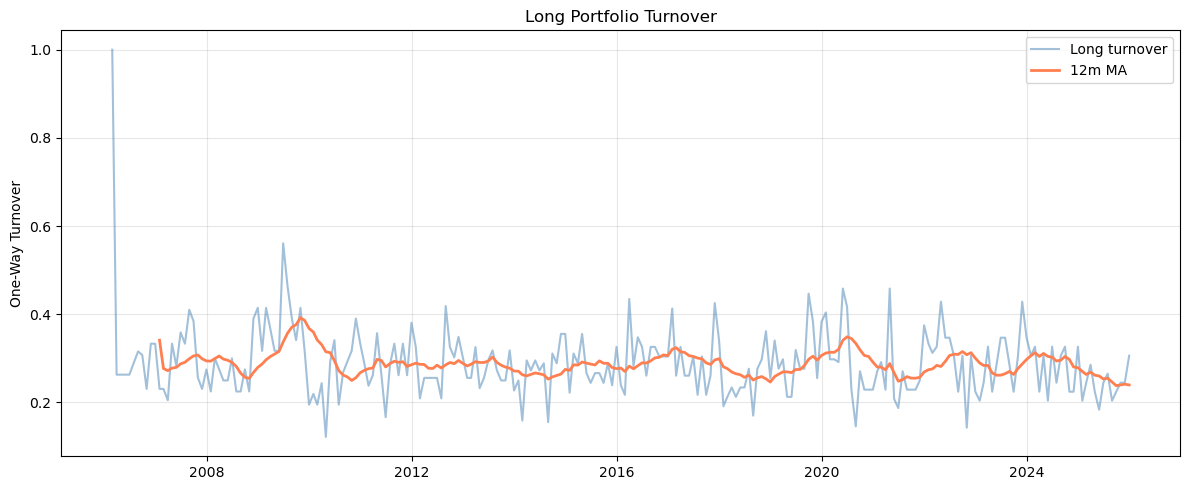

Average long turnover (one-way): 0.289
Average L/S turnover (one-way):   0.596


In [5]:
"""
==================================
Compute one-way turnover at each rebalance
==================================
"""
def _equal_weight_vector(holdings):
    """Equal-weight vector for a list of holdings."""
    if len(holdings) == 0:
        return pd.Series(dtype=float)
    return pd.Series(1.0 / len(holdings), index=pd.Index(holdings), dtype=float)

def compute_turnover(holdings_series):
    """Compute one-way turnover from actual target weight vectors."""
    turnovers = []
    prev_w = None
    for holdings in holdings_series:
        curr_w = _equal_weight_vector(holdings)
        if curr_w.empty:
            turnover = 0.0
        elif prev_w is None or prev_w.empty:
            turnover = curr_w.abs().sum()  # initial buy into the portfolio
        else:
            names = prev_w.index.union(curr_w.index)
            turnover = (curr_w.reindex(names, fill_value=0.0) - prev_w.reindex(names, fill_value=0.0)).abs().sum() / 2.0
        turnovers.append(float(turnover))
        prev_w = curr_w
    return pd.Series(turnovers, index=holdings_series.index)

df_port['long_turnover'] = compute_turnover(df_port['long_holdings'])
df_port['short_turnover'] = compute_turnover(df_port['short_holdings'])
df_port['ls_turnover'] = df_port['long_turnover'] + df_port['short_turnover']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_port.index, df_port['long_turnover'], color='steelblue', alpha=0.5, label='Long turnover')
ax.plot(df_port.index, df_port['long_turnover'].rolling(12).mean(), color='coral', linewidth=2, label='12m MA')
ax.set_ylabel('One-Way Turnover')
ax.set_title('Long Portfolio Turnover')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/04_backtest/turnover.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average long turnover (one-way): {df_port['long_turnover'].mean():.3f}")
print(f"Average L/S turnover (one-way):   {df_port['ls_turnover'].mean():.3f}")

In [6]:
"""
==================================
Apply transaction costs
==================================

Cost = one-way turnover * cost in bps / 10000.
For the long-short book, long and short costs are applied separately.
"""
tc = TRANSACTION_COST_BPS / 10000  # 5 bps = 0.0005

# Net returns = gross - cost
df_port['long_net'] = df_port['long'] - df_port['long_turnover'] * tc
df_port['short_net'] = df_port['short'] + df_port['short_turnover'] * tc  # Short pays cost too
df_port['ls_net'] = df_port['long_net'] - df_port['short_net']

# Excess returns (subtract risk-free)
# Align FF data (month-start) to portfolio index (month-end) via period index
df_port_pm = df_port.copy()
df_port_pm.index = df_port_pm.index.to_period('M')
ff_pm = df_ff[['RF', 'Mkt-RF']].copy()
ff_pm.index = ff_pm.index.to_period('M')
df_port['RF'] = ff_pm['RF'].reindex(df_port_pm.index).values
df_port['Mkt-RF'] = ff_pm['Mkt-RF'].reindex(df_port_pm.index).values
df_port['long_excess'] = df_port['long_net'] - df_port['RF']
df_port['short_excess'] = df_port['short_net'] - df_port['RF']
df_port['ls_excess'] = df_port['ls_net']  # L/S is dollar-neutral, RF cancels

print("Net return summary:")
display(df_port[['long_net', 'short_net', 'ls_net']].describe().round(4))

Net return summary:


,long_net,short_net,ls_net
count,239.0000,239.0000,239.0000
mean,0.0162,0.0169,-0.0007
std,0.0560,0.0700,0.0479
min,-0.1797,-0.2208,-0.4088
25%,-0.0117,-0.0209,-0.0217
50%,0.0174,0.0144,0.0019
75%,0.0496,0.0488,0.0247
max,0.1725,0.4797,0.1005


## Performance Metrics

The main metrics are:

- **Sharpe ratio:**

$$\text{Sharpe}=\frac{\bar r_p}{\mathrm{std}(r_p)}\sqrt{12}.$$

- **Sortino ratio:** like Sharpe, but the denominator is downside deviation rather than total volatility.
- **Max drawdown:** the worst percentage drop from a previous wealth peak:

$$\text{DD}_t=\frac{V_t-\max_{s\le t}V_s}{\max_{s\le t}V_s}, \quad V_t=\prod_{s=1}^{t}(1+r_{p,s}).$$

- **Calmar ratio:** annualized return divided by the absolute value of max drawdown.

These are descriptive statistics. They do not prove a strategy is good, but they help us understand the shape of the returns.

## Sortino Ratio and Max Drawdown

### Sortino Ratio

Sharpe uses total volatility in the denominator. That means upside and downside moves both increase the denominator. Sortino replaces total volatility with downside deviation, so months above the target return do not count as risk.

With target return $r_{\text{target}}=0$:

$$\sigma_D=\sqrt{\frac{1}{T}\sum_{t=1}^{T}\min(0,r_t-r_{\text{target}})^2},$$

and

$$\text{Sortino}=\frac{\bar r_p}{\sigma_D}\sqrt{12}.$$

Example monthly returns:

$$[0.03,-0.02,0.08,-0.01,0.04].$$

Only the negative months enter downside deviation:

| Month | Return | Downside part | Squared |
|---|---:|---:|---:|
| 1 | 0.03 | 0.00 | 0.0000 |
| 2 | -0.02 | -0.02 | 0.0004 |
| 3 | 0.08 | 0.00 | 0.0000 |
| 4 | -0.01 | -0.01 | 0.0001 |
| 5 | 0.04 | 0.00 | 0.0000 |

So

$$\sigma_D=\sqrt{(0.0004+0.0001)/5}=0.01.$$

Sortino is useful when the return distribution is asymmetric. A large gap between Sortino and Sharpe usually means the strategy has more upside volatility than downside volatility.

### Max Drawdown

Cumulative wealth is

$$V_t=(1+r_1)(1+r_2)\cdots(1+r_t).$$

The running peak is

$$P_t=\max_{s\le t}V_s.$$

Drawdown is the percentage distance below that peak:

$$\text{DD}_t=\frac{V_t-P_t}{P_t}.$$

Example:

| Month | Wealth $V_t$ | Running peak $P_t$ | Drawdown |
|---|---:|---:|---:|
| 1 | 1.05 | 1.05 | 0.0% |
| 2 | 1.08 | 1.08 | 0.0% |
| 3 | 1.02 | 1.08 | -5.6% |
| 4 | 0.95 | 1.08 | -12.0% |
| 5 | 1.01 | 1.08 | -6.5% |

Max drawdown is the worst value in that drawdown series. It answers: how far underwater would an investor have been at the worst point?

Calmar then asks how much annual return the strategy earned per unit of that worst drawdown:

$$\text{Calmar}=\frac{\text{annualized return}}{|\text{max drawdown}|}.$$

### Equal-Weight (EW) Universe Benchmark

The equal-weight universe holds every available stock at the same weight:

$$w_i=\frac{1}{N_t}.$$

Its return is the row mean of the return matrix:

$$\bar r_t=\frac{1}{N_t}\mathbf{1}^\top r_t.$$

This is a better benchmark for this project than a cap-weighted index because our portfolio is also equal-weighted within its selected names. Comparing equal-weight to equal-weight keeps the focus on selection: did the top-momentum decile beat simply holding the whole available universe equally?

The difference $r_{p,t}-\bar r_t$ is the **active return**, and its annualized mean divided by tracking error is the **information ratio**.

In [7]:
"""
==================================
Compute performance metrics
==================================
"""
def performance_metrics(returns, freq=12, rf=0):
    """Compute standard performance metrics."""
    returns = returns.dropna()
    excess = returns - rf
    ann_return = returns.mean() * freq
    ann_vol = returns.std() * np.sqrt(freq)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    downside = np.minimum(excess, 0.0)
    downside_vol = np.sqrt(np.mean(downside ** 2)) * np.sqrt(freq) if len(downside) > 0 else np.nan
    sortino = ann_return / downside_vol if downside_vol and downside_vol > 0 else np.nan

    cum = (1 + returns).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = drawdown.min()
    
    calmar = ann_return / abs(max_dd) if max_dd < 0 else np.nan
    
    return {
        'ann_return': ann_return,
        'ann_vol': ann_vol,
        'sharpe': sharpe,
        'sortino': sortino,
        'max_drawdown': max_dd,
        'calmar': calmar
    }

# Equal-weight universe benchmark — align via period index
ew_monthly = df_returns.mean(axis=1)
ew_monthly.index = ew_monthly.index.to_period('M')
df_port['ew_universe'] = ew_monthly.reindex(df_port.index.to_period('M')).values

# Compute metrics for all portfolios
metrics = {}
for col, label in [('long_net', 'Long-Only (net)'), ('ls_net', 'Long-Short (net)'), ('ew_universe', 'EW Universe')]:
    metrics[col] = performance_metrics(df_port[col])

df_metrics = pd.DataFrame(metrics).T.round(4)
print("Performance Summary\n")
display(df_metrics)

# Active return vs equal-weight universe
df_port['active'] = df_port['long_net'] - df_port['ew_universe']
active = df_port['active'].dropna()
t_stat = active.mean() / (active.std() / np.sqrt(len(active)))
ir = active.mean() / active.std() * np.sqrt(12)
print(f"\nActive Return (Long-Only minus EW Universe)")
print(f"  Monthly active return: {active.mean():.5f} (t = {t_stat:.2f})")
print(f"  Annualized:            {active.mean()*12:.4f}")
print(f"  Tracking error:        {active.std()*np.sqrt(12):.4f}")
print(f"  Information ratio:     {ir:.4f}")

Performance Summary



,ann_return,ann_vol,sharpe,sortino,max_drawdown,calmar
long_net,0.1948,0.1941,1.0036,1.6436,-0.5713,0.3409
ls_net,-0.0081,0.1658,-0.0491,-0.0590,-0.7029,-0.0116
ew_universe,0.1594,0.1683,0.9471,1.5203,-0.4747,0.3359



Active Return (Long-Only minus EW Universe)
  Monthly active return: 0.00295 (t = 1.89)
  Annualized:            0.0354
  Tracking error:        0.0833
  Information ratio:     0.4243


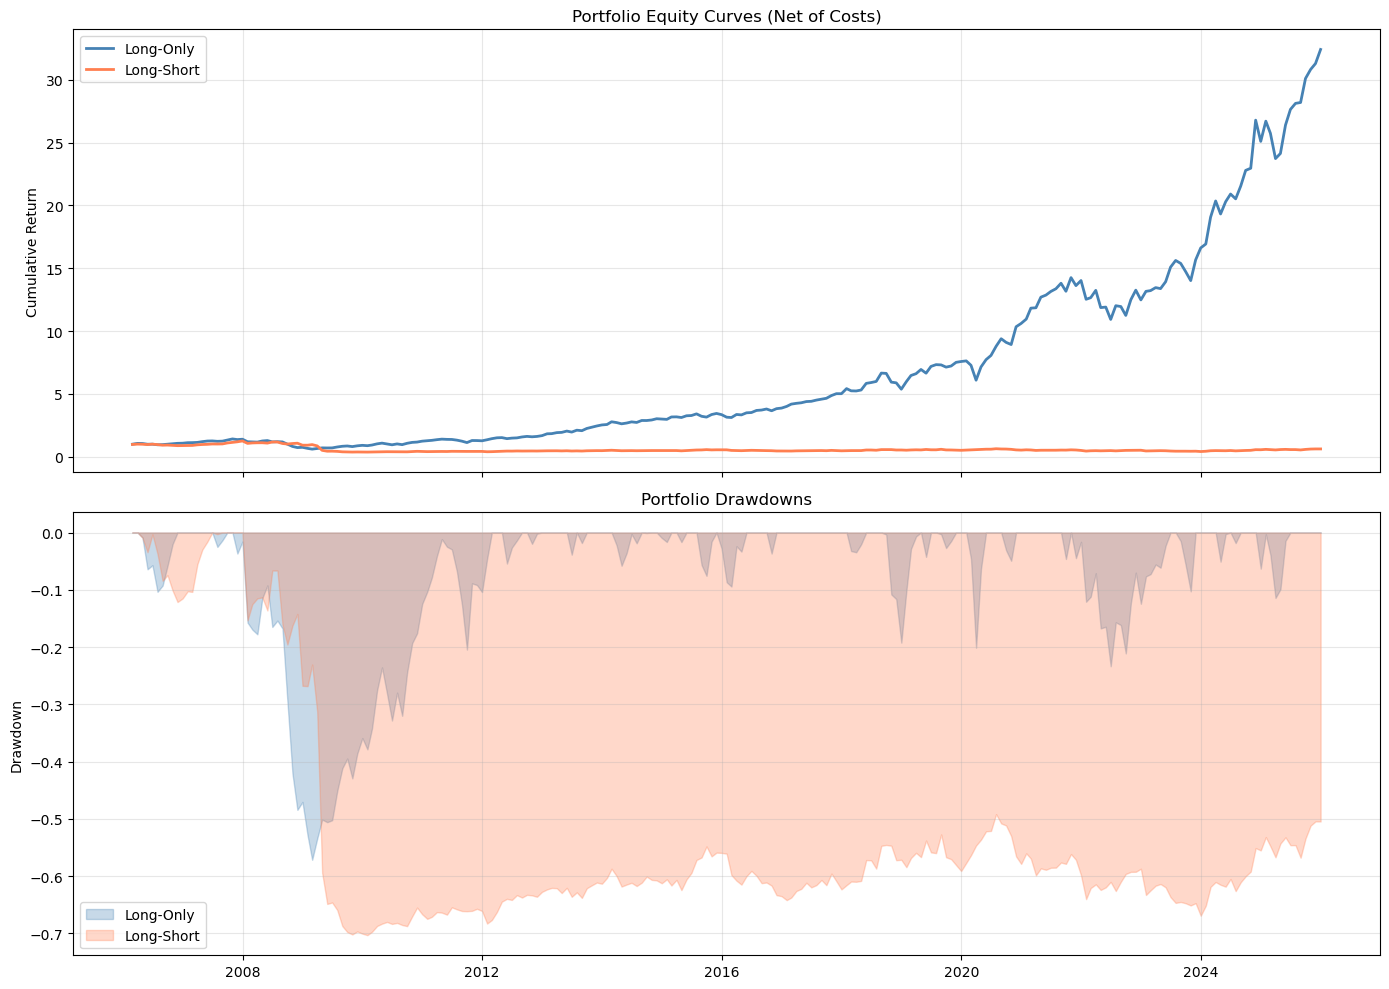

In [8]:
"""
==================================
Equity curve and drawdown
==================================
"""
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Cumulative returns
ax = axes[0]
for col, color, label in [('long_net', 'steelblue', 'Long-Only'), ('ls_net', 'coral', 'Long-Short')]:
    cum = (1 + df_port[col]).cumprod()
    ax.plot(cum.index, cum.values, color=color, linewidth=2, label=label)
ax.set_ylabel('Cumulative Return')
ax.set_title('Portfolio Equity Curves (Net of Costs)')
ax.legend()
ax.grid(alpha=0.3)

# Drawdown
ax = axes[1]
for col, color, label in [('long_net', 'steelblue', 'Long-Only'), ('ls_net', 'coral', 'Long-Short')]:
    cum = (1 + df_port[col]).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax()
    ax.fill_between(dd.index, dd.values, 0, color=color, alpha=0.3, label=label)
ax.set_ylabel('Drawdown')
ax.set_title('Portfolio Drawdowns')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/04_backtest/equity_and_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

## Walk-Forward Analysis

A full-sample Sharpe can be misleading if one period did all the work. Walk-forward analysis splits the history into 5-year windows and recomputes performance in each window.

This is a consistency check, not a parameter search. The question is whether the strategy works across more than one regime.

Walk-Forward Performance (5-Year Windows)



,lo_sharpe,lo_ann_ret,ls_sharpe,ew_sharpe,active_ret,info_ratio,active_t
period,,,,,,,
2006-2011,0.3108,0.0703,-0.5493,0.5729,-0.0495,-0.5230,-1.1596
2011-2016,1.4347,0.2105,0.6602,1.3470,0.0420,0.7802,1.7445
2016-2021,1.2810,0.2515,-0.0018,1.1172,0.0592,0.7994,1.7874
2021-2026,1.2279,0.2447,0.2942,0.9738,0.0883,0.8852,1.9795


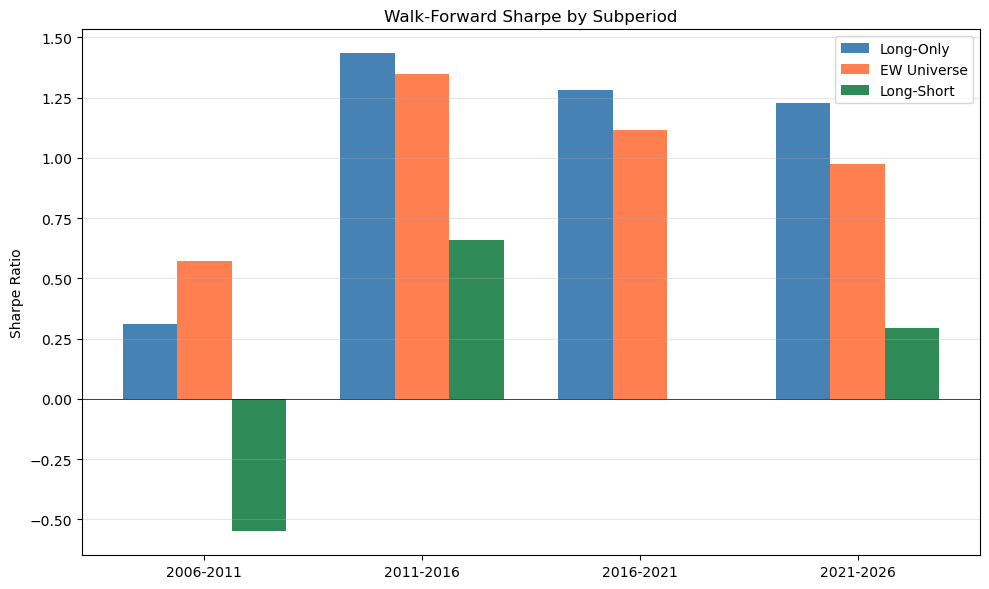


Long-Only Sharpe positive in 4/4 windows
Active return positive in 3/4 windows


In [9]:
"""
==================================
Walk-forward analysis: 5-year windows
==================================
"""
windows = [(2006, 2011), (2011, 2016), (2016, 2021), (2021, 2026)]

wf_results = []
for start, end in windows:
    mask = (df_port.index.year >= start) & (df_port.index.year < end)
    if mask.sum() < 12:
        continue
    
    m_lo = performance_metrics(df_port.loc[mask, 'long_net'])
    m_ls = performance_metrics(df_port.loc[mask, 'ls_net'])
    m_ew = performance_metrics(df_port.loc[mask, 'ew_universe'])
    
    active_sub = df_port.loc[mask, 'active'].dropna()
    ir = active_sub.mean() / active_sub.std() * np.sqrt(12) if len(active_sub) > 12 and active_sub.std() > 0 else np.nan
    t_act = active_sub.mean() / (active_sub.std() / np.sqrt(len(active_sub))) if len(active_sub) > 12 else np.nan
    
    wf_results.append({
        'period': f'{start}-{end}',
        'lo_sharpe': m_lo['sharpe'],
        'lo_ann_ret': m_lo['ann_return'],
        'ls_sharpe': m_ls['sharpe'],
        'ew_sharpe': m_ew['sharpe'],
        'active_ret': active_sub.mean() * 12,
        'info_ratio': ir,
        'active_t': t_act
    })

df_wf = pd.DataFrame(wf_results).set_index('period')
print("Walk-Forward Performance (5-Year Windows)\n")
display(df_wf.round(4))

# Plot walk-forward Sharpe ratios
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_wf))
width = 0.25
ax.bar(x - width, df_wf['lo_sharpe'], width, label='Long-Only', color='steelblue')
ax.bar(x, df_wf['ew_sharpe'], width, label='EW Universe', color='coral')
ax.bar(x + width, df_wf['ls_sharpe'], width, label='Long-Short', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(df_wf.index)
ax.set_ylabel('Sharpe Ratio')
ax.set_title('Walk-Forward Sharpe by Subperiod')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../images/04_backtest/walk_forward.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLong-Only Sharpe positive in {(df_wf['lo_sharpe'] > 0).sum()}/{len(df_wf)} windows")
print(f"Active return positive in {(df_wf['active_ret'] > 0).sum()}/{len(df_wf)} windows")

## Reconciling Walk-Forward IC vs. Walk-Forward Sharpe

Notebook 02 found that momentum's monthly IC was positive in only some subperiods, while the long-only portfolio Sharpe can still be positive across all windows. Those are not contradictory.

IC measures cross-sectional ordering: did higher-ranked stocks beat lower-ranked stocks? Portfolio Sharpe measures the return level of the selected stocks. A top-decile book can make money in a window even if its ranking skill is weak, especially if the selected stocks had high market beta during a rising market.

The table below compares mean IC, portfolio Sharpe, and realized market beta by window. If high beta lines up with weak IC, the Sharpe is probably being carried by market exposure rather than stock selection.

In [10]:
"""
==================================
Reconcile factor-level IC (notebook 02) with portfolio-level Sharpe, by window
==================================
"""
df_ic_momentum = pd.read_csv('../data/processed/ic_monthly.csv', index_col=0, parse_dates=True)['momentum']

reconcile_rows = []
for start, end in windows:
    mask_port = (df_port.index.year >= start) & (df_port.index.year < end)
    mask_ic = (df_ic_momentum.index.year >= start) & (df_ic_momentum.index.year < end)

    sub_port = df_port.loc[mask_port].dropna(subset=['long_excess', 'Mkt-RF'])
    sub_ic = df_ic_momentum.loc[mask_ic].dropna()

    if len(sub_port) > 3 and sub_port['Mkt-RF'].var() > 0:
        port_beta = sub_port['long_excess'].cov(sub_port['Mkt-RF']) / sub_port['Mkt-RF'].var()
    else:
        port_beta = np.nan

    reconcile_rows.append({
        'period': f'{start}-{end}',
        'mean_ic': sub_ic.mean(),
        'portfolio_sharpe': performance_metrics(df_port.loc[mask_port, 'long_net'])['sharpe'],
        'portfolio_mkt_beta': port_beta,
    })

df_reconcile = pd.DataFrame(reconcile_rows).set_index('period')
print("IC vs. Sharpe vs. realized market beta, by walk-forward window:\n")
display(df_reconcile.round(3))

print(
    "\nIf portfolio_mkt_beta is visibly higher in the windows where mean_ic is negative, "
    "that is the mechanical explanation: the decile's Sharpe in that window is being carried "
    "by market exposure rather than by the ranking signal actually working that period."
)


IC vs. Sharpe vs. realized market beta, by walk-forward window:



,mean_ic,portfolio_sharpe,portfolio_mkt_beta
period,,,
2006-2011,-0.013,0.311,1.144
2011-2016,0.028,1.435,1.105
2016-2021,-0.008,1.281,1.127
2021-2026,0.017,1.228,1.171



If portfolio_mkt_beta is visibly higher in the windows where mean_ic is negative, that is the mechanical explanation: the decile's Sharpe in that window is being carried by market exposure rather than by the ranking signal actually working that period.


## Fama-French Alpha

The Fama-French regression is an OLS regression of portfolio excess returns on benchmark factor returns. Given factor matrix $F \in \mathbb{R}^{T\times k}$ and portfolio excess returns $y\in\mathbb{R}^T$, the fitted model is

$$y=\alpha\mathbf{1}+F\beta+\varepsilon.$$

The least-squares beta estimate is

$$\hat\beta=(F^\top F)^{-1}F^\top(y-\alpha\mathbf{1}),$$

or equivalently the full coefficient vector is estimated after adding a column of ones to $F$.

- **Betas:** exposures to benchmark factors such as market, size, value, and momentum.
- **Alpha:** the intercept. It is the average return left after controlling for those factor exposures.
- **Residuals:** the month-by-month unexplained returns around the fitted line.

So alpha is related to the residual, but it is not the entire residual vector. It is the average unexplained return, annualized here by multiplying the monthly intercept by 12.

We report the usual OLS t-statistic and a **HAC/Newey-West** t-statistic with three monthly lags. HAC standard errors are a useful check because monthly portfolio residuals can have mild autocorrelation or changing volatility. If the alpha only survives under plain OLS and disappears under HAC, the result is less convincing.

We run this on the long-only portfolio as the headline result and on the long-short portfolio as a comparison.

In [11]:
"""
==================================
Fama-French 4-factor regression: Long-Only and Long-Short
==================================
"""
import statsmodels.api as sm

FF_FACTOR_COLS = ['Mkt-RF', 'SMB', 'HML', 'Mom']
HAC_LAGS = 3

# --- Robust alignment via year-month period index ---
# df_port has month-end dates, df_ff has month-start dates.
# Align both to PeriodIndex('M') so they match regardless of timestamp conventions.
df_port_pm = df_port.copy()
df_port_pm.index = df_port_pm.index.to_period('M')

df_ff_pm = df_ff[FF_FACTOR_COLS].copy()
df_ff_pm.index = df_ff_pm.index.to_period('M')

df_reg = df_port_pm.join(df_ff_pm, how='inner', lsuffix='_port', rsuffix='_ff')

# Resolve any column-name collisions (Mkt-RF may exist in both from cell 10)
for col in FF_FACTOR_COLS:
    if col + '_ff' in df_reg.columns:
        df_reg[col] = df_reg[col + '_ff']

df_reg = df_reg[['long_excess', 'ls_net'] + FF_FACTOR_COLS].dropna().astype(float)

print(f"Regression data points: {len(df_reg)}")


def fit_ff_model(y):
    """Fit FF regression with ordinary and HAC/Newey-West covariance."""
    X = sm.add_constant(df_reg[FF_FACTOR_COLS], has_constant='add')
    ols = sm.OLS(y, X).fit()
    hac = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_LAGS})
    return ols, hac


def print_ff_model(label, model, model_hac, show_all_betas=True):
    print("=" * 60)
    print(label)
    print("=" * 60)
    print(f"  Alpha (monthly):       {model.params['const']:.5f}")
    print(f"  Alpha (annualized):    {model.params['const']*12:.4f}")
    print(f"  Alpha t-stat (OLS):    {model.tvalues['const']:.2f}")
    print(f"  Alpha t-stat (HAC):    {model_hac.tvalues['const']:.2f}  (Newey-West, {HAC_LAGS} lags)")
    print(f"  MKT beta:              {model.params['Mkt-RF']:.3f} (t={model.tvalues['Mkt-RF']:.2f})")
    if show_all_betas:
        print(f"  SMB beta:              {model.params['SMB']:.3f} (t={model.tvalues['SMB']:.2f})")
        print(f"  HML beta:              {model.params['HML']:.3f} (t={model.tvalues['HML']:.2f})")
        print(f"  MOM beta:              {model.params['Mom']:.3f} (t={model.tvalues['Mom']:.2f})")
    else:
        print(f"  MOM beta:              {model.params['Mom']:.3f} (t={model.tvalues['Mom']:.2f})")
    print(f"  R^2:                   {model.rsquared:.3f}")

if len(df_reg) == 0:
    print("ERROR: No overlapping data between backtest and Fama-French factors.")
    print("Check the indices of df_port and df_ff.")
else:
    model_lo, model_lo_hac = fit_ff_model(df_reg['long_excess'])
    print_ff_model("LONG-ONLY: Fama-French 4-Factor Alpha", model_lo, model_lo_hac)

    model_ls, model_ls_hac = fit_ff_model(df_reg['ls_net'])
    print()
    print_ff_model("LONG-SHORT: Fama-French 4-Factor Alpha (comparison)", model_ls, model_ls_hac, show_all_betas=False)

    print(f"\n{'=' * 60}")
    print("SUMMARY")
    print(f"  Long-only alpha:  {model_lo.params['const']*12:+.4f} "
          f"(OLS t={model_lo.tvalues['const']:.2f}, HAC t={model_lo_hac.tvalues['const']:.2f})")
    print(f"  Long-short alpha: {model_ls.params['const']*12:+.4f} "
          f"(OLS t={model_ls.tvalues['const']:.2f}, HAC t={model_ls_hac.tvalues['const']:.2f})")
    print("=" * 60)

Regression data points: 239
LONG-ONLY: Fama-French 4-Factor Alpha
  Alpha (monthly):       0.00497
  Alpha (annualized):    0.0597
  Alpha t-stat (OLS):    3.98
  Alpha t-stat (HAC):    4.17  (Newey-West, 3 lags)
  MKT beta:              1.189 (t=39.27)
  SMB beta:              0.262 (t=5.02)
  HML beta:              -0.045 (t=-1.12)
  MOM beta:              0.251 (t=7.95)
  R^2:                   0.889

LONG-SHORT: Fama-French 4-Factor Alpha (comparison)
  Alpha (monthly):       -0.00246
  Alpha (annualized):    -0.0295
  Alpha t-stat (OLS):    -1.41
  Alpha t-stat (HAC):    -1.37  (Newey-West, 3 lags)
  MKT beta:              0.144 (t=3.42)
  MOM beta:              0.905 (t=20.62)
  R^2:                   0.704

SUMMARY
  Long-only alpha:  +0.0597 (OLS t=3.98, HAC t=4.17)
  Long-short alpha: -0.0295 (OLS t=-1.41, HAC t=-1.37)


### What Does MKT Beta = 1.19 Mean for the Headline Alpha?

The regression reports a market beta along with alpha. A beta around 1.19 means the long-only decile had about 19% more market exposure than a beta-1 portfolio over this sample.

That matters because part of the raw return may be ordinary market risk, not stock selection. This is why the factor-adjusted alpha is more informative than the raw active return. The regression subtracts the part explained by market, size, value, and momentum exposure before estimating the intercept.

To make the idea concrete, we compare the portfolio to a beta-matched benchmark: the equal-weight universe scaled to the same market beta. This is not a tradable recommendation; it is a diagnostic for whether the outperformance survives a simple market-risk adjustment.

In [12]:
"""
==================================
Beta-matched benchmark comparison
==================================
"""
beta_lo = model_lo.params['Mkt-RF']  # MKT-RF coefficient from the FF regression above

ew_scaled = df_port['ew_universe'] * beta_lo

lo_ann_ret = df_port['long_net'].mean() * 12
ew_ann_ret = df_port['ew_universe'].mean() * 12
ew_scaled_ann_ret = ew_scaled.mean() * 12

print(f"Long-only ann. return:                {lo_ann_ret:.4f}")
print(f"EW universe ann. return (unscaled):    {ew_ann_ret:.4f}")
print(f"EW universe ann. return (x{beta_lo:.2f} beta-matched): {ew_scaled_ann_ret:.4f}")
print(f"\nOutperformance vs. unscaled EW:        {lo_ann_ret - ew_ann_ret:+.4f}")
print(f"Outperformance vs. beta-matched EW:     {lo_ann_ret - ew_scaled_ann_ret:+.4f}")
print(
    "\nIf the beta-matched gap is still clearly positive, the outperformance is not simply "
    "leverage on the market factor; this is a second, more direct check on the same question "
    "the FF alpha answers via regression."
)


Long-only ann. return:                0.1948
EW universe ann. return (unscaled):    0.1594
EW universe ann. return (x1.19 beta-matched): 0.1895

Outperformance vs. unscaled EW:        +0.0354
Outperformance vs. beta-matched EW:     +0.0052

If the beta-matched gap is still clearly positive, the outperformance is not simply leverage on the market factor; this is a second, more direct check on the same question the FF alpha answers via regression.


## Survivorship Bias Sensitivity

The universe is based on current S&P 500 constituents. That means stocks that disappeared from the index, were acquired, delisted, or went bankrupt may be missing from the historical panel.

We cannot fully fix this without survivorship-free data. Instead, we ask a sensitivity question: how much annual return drag would we need to subtract before the Fama-French alpha is no longer statistically significant?

This is not a perfect model of delisting bias. It is a breakeven calculation. If a small drag erases the result, the backtest is fragile. If a large drag is needed, the result is less likely to be explained only by survivorship bias.

### Survivorship Bias Sensitivity

How much annual return drag from missing delisted stocks would erase the alpha?



,annual_drag,alpha_monthly,alpha_annualized,t_stat_ols,t_stat_hac,significant_hac
0,0.0%,0.0050,0.0597,3.9777,4.1656,Yes
1,0.5%,0.0046,0.0547,3.6444,3.8166,Yes
2,1.0%,0.0041,0.0497,3.3111,3.4676,Yes
3,2.0%,0.0033,0.0397,2.6446,2.7695,Yes
4,3.0%,0.0025,0.0297,1.9780,2.0714,Yes
5,4.0%,0.0016,0.0197,1.3114,1.3734,No
6,5.0%,0.0008,0.0097,0.6449,0.6753,No


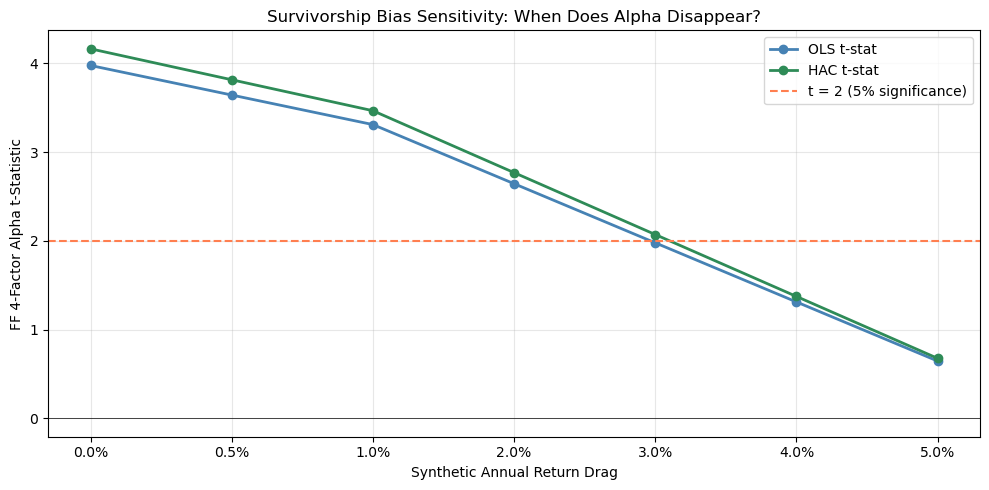

In [13]:
"""
==================================
Survivorship bias sensitivity
==================================
"""
drags = [0, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05]
sensitivity = []

# Reuse the aligned FF regression frame built in the alpha cell;
# rebuild it if this cell is run standalone.
if 'df_reg' not in globals():
    _pm = df_port.copy(); _pm.index = _pm.index.to_period('M')
    _ff = df_ff[['Mkt-RF', 'SMB', 'HML', 'Mom']].copy(); _ff.index = _ff.index.to_period('M')
    df_reg = _pm.join(_ff, how='inner', lsuffix='_port', rsuffix='_ff')
    for _c in ['Mkt-RF', 'SMB', 'HML', 'Mom']:
        if _c + '_ff' in df_reg.columns:
            df_reg[_c] = df_reg[_c + '_ff']
    df_reg = df_reg[['long_excess', 'Mkt-RF', 'SMB', 'HML', 'Mom']].dropna().astype(float)

X_factors = sm.add_constant(df_reg[['Mkt-RF', 'SMB', 'HML', 'Mom']])

for drag in drags:
    y_adj = df_reg['long_excess'] - drag / 12  # monthly drag on excess returns
    model = sm.OLS(y_adj, X_factors).fit()
    model_hac = sm.OLS(y_adj, X_factors).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_LAGS})
    alpha_m = model.params['const']
    alpha_t = model.tvalues['const']
    sensitivity.append({
        'annual_drag': f'{drag*100:.1f}%',
        'alpha_monthly': alpha_m,
        'alpha_annualized': alpha_m * 12,
        't_stat_ols': alpha_t,
        't_stat_hac': model_hac.tvalues['const'],
        'significant_hac': 'Yes' if abs(model_hac.tvalues['const']) > 2 else 'No'
    })

df_sens = pd.DataFrame(sensitivity)
print("### Survivorship Bias Sensitivity\n")
print("How much annual return drag from missing delisted stocks would erase the alpha?\n")
display(df_sens.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_sens['annual_drag'], df_sens['t_stat_ols'], 'o-', color='steelblue', linewidth=2, label='OLS t-stat')
ax.plot(df_sens['annual_drag'], df_sens['t_stat_hac'], 'o-', color='seagreen', linewidth=2, label='HAC t-stat')
ax.axhline(y=2, color='coral', linestyle='--', label='t = 2 (5% significance)')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Synthetic Annual Return Drag')
ax.set_ylabel('FF 4-Factor Alpha t-Statistic')
ax.set_title('Survivorship Bias Sensitivity: When Does Alpha Disappear?')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/04_backtest/survivorship_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

### Concentrating the Drag in Bad Months

A flat monthly drag is easy to read, but real delisting losses are not evenly spread through time. They tend to cluster during market stress.

So we run a harsher version: apply most of the same annual drag during the worst equal-weight universe months and only a small residual drag elsewhere. If this concentrated drag erases the alpha much faster, the flat-drag test was too generous.

In [14]:
"""
==================================
Concentrated (crash-weighted) survivorship drag sensitivity
==================================
"""
crash_mask = df_reg.index.map(
    lambda p: df_port_pm.loc[p, 'ew_universe'] if p in df_port_pm.index else np.nan
)
crash_mask = pd.Series(crash_mask, index=df_reg.index)
crash_threshold = crash_mask.quantile(0.25)
is_crash_month = crash_mask < crash_threshold

concentrated_sensitivity = []
for drag in drags:
    monthly_drag = drag / 12
    y_adj = df_reg['long_excess'].copy()
    # ~80% of the total drag falls in the worst quartile of months, 20% spread over the rest
    n_crash = is_crash_month.sum()
    n_other = (~is_crash_month).sum()
    if n_crash > 0:
        y_adj[is_crash_month] -= monthly_drag * len(y_adj) * 0.8 / n_crash
    if n_other > 0:
        y_adj[~is_crash_month] -= monthly_drag * len(y_adj) * 0.2 / n_other

    model = sm.OLS(y_adj, X_factors).fit()
    model_hac = sm.OLS(y_adj, X_factors).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_LAGS})
    alpha_m = model.params['const']
    concentrated_sensitivity.append({
        'annual_drag': f'{drag*100:.1f}%',
        'alpha_annualized': alpha_m * 12,
        'alpha_t_ols': model.tvalues['const'],
        'alpha_t_hac': model_hac.tvalues['const'],
        'significant_hac_t_gt_2': abs(model_hac.tvalues['const']) > 2,
    })

df_concentrated_sensitivity = pd.DataFrame(concentrated_sensitivity)
print("Concentrated (crash-weighted) drag sensitivity:\n")
display(df_concentrated_sensitivity.round(4))
print(
    "\nCompare the drag level at which significance is lost here against the flat-drag table above. "
    "A meaningfully lower breakeven drag under concentration would mean the flat-drag result "
    "overstates how robust the alpha is to realistic (crash-clustered) survivorship bias."
)


Concentrated (crash-weighted) drag sensitivity:



,annual_drag,alpha_annualized,alpha_t_ols,alpha_t_hac,significant_hac_t_gt_2
0,0.0%,0.0597,3.9777,4.1656,True
1,0.5%,0.0538,3.5921,3.7664,True
2,1.0%,0.0479,3.2042,3.3635,True
3,2.0%,0.0362,2.4227,2.5481,True
4,3.0%,0.0244,1.6364,1.7237,False
5,4.0%,0.0127,0.8484,0.8946,False
6,5.0%,0.0009,0.0618,0.0652,False



Compare the drag level at which significance is lost here against the flat-drag table above. A meaningfully lower breakeven drag under concentration would mean the flat-drag result overstates how robust the alpha is to realistic (crash-clustered) survivorship bias.


In [15]:
"""
==================================
Save backtest returns for risk decomposition
==================================
"""
df_port[['long_net', 'short_net', 'ls_net', 'long_excess', 'ls_excess']].to_csv(
    '../data/processed/backtest_returns.csv'
)

print("Saved backtest returns to ../data/processed/backtest_returns.csv")

Saved backtest returns to ../data/processed/backtest_returns.csv


## Robustness: Decile Size and Rebalance Timing

The headline portfolio uses one specific set of choices: top 10%, monthly rebalance, equal-weight holdings. Before leaning on the alpha, we should vary the nearby choices that do not require new data.

This grid varies:

- **Decile cutoff:** 5%, 10%, 15%, 20%.
- **Rebalance interval:** every 1, 2, or 3 months.

For each combination, we recompute net returns, Sharpe, max drawdown, Fama-French alpha, ordinary OLS t-stat, HAC/Newey-West t-stat, and market beta.

This still does not solve universe-construction robustness. The current-constituent universe remains a limitation. But it does answer whether the result depends on exactly one decile/rebalance setting.

Long-only robustness across decile size and rebalance interval:



,decile,rebalance_every_months,n_observations,ann_return,sharpe,max_drawdown,alpha_annualized,alpha_t_ols,alpha_t_hac,mkt_beta,r_squared
0,5%,1,239,0.2196,1.0230,-0.5937,0.0788,3.8136,4.0575,1.2460,0.8271
1,5%,2,239,0.1984,0.9023,-0.6431,0.0547,2.6498,2.8879,1.2814,0.8355
2,5%,3,239,0.2165,1.0064,-0.5946,0.0726,3.6577,3.7432,1.2724,0.8410
3,10%,1,239,0.1948,1.0036,-0.5713,0.0597,3.9777,4.1656,1.1889,0.8885
4,10%,2,239,0.1827,0.9256,-0.6137,0.0460,2.9278,2.9244,1.2077,0.8818
5,10%,3,239,0.1872,0.9568,-0.5974,0.0489,3.3811,3.1063,1.2160,0.8979
6,15%,1,239,0.1825,0.9848,-0.5664,0.0497,3.8816,3.8900,1.1650,0.9109
7,15%,2,239,0.1802,0.9652,-0.5650,0.0473,3.7551,3.9190,1.1693,0.9150
8,15%,3,239,0.1808,0.9730,-0.5530,0.0477,3.8894,3.8909,1.1682,0.9187
9,20%,1,239,0.1745,0.9718,-0.5507,0.0458,3.9347,4.0960,1.1302,0.9217


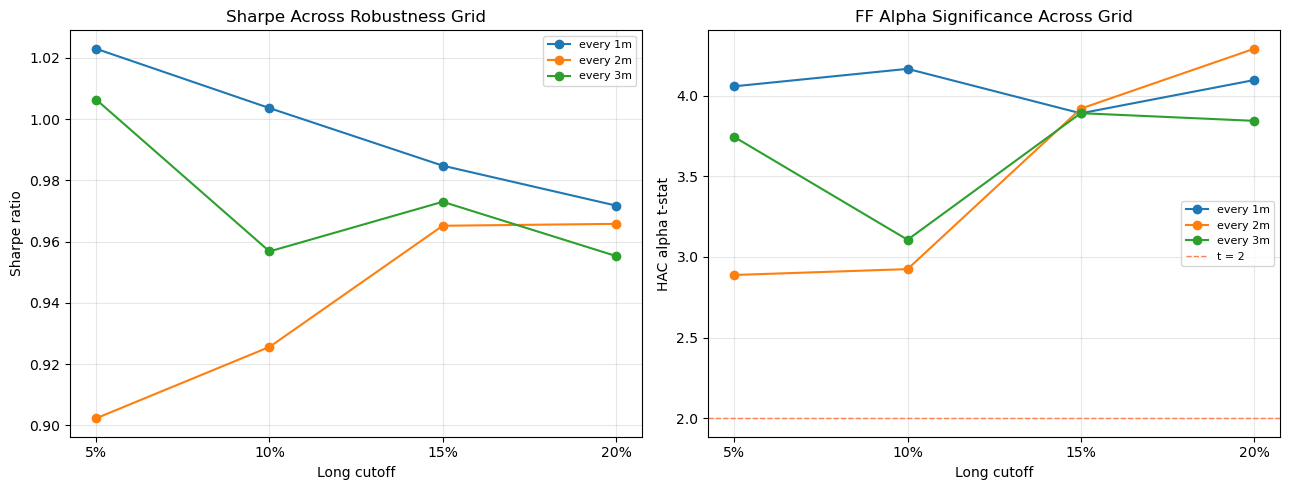

Headline setting from grid:


,decile,rebalance_every_months,n_observations,ann_return,sharpe,max_drawdown,alpha_annualized,alpha_t_ols,alpha_t_hac,mkt_beta,r_squared
3,10%,1,239,0.1948,1.0036,-0.5713,0.0597,3.9777,4.1656,1.1889,0.8885



Interpretation: robust results should not require exactly one cutoff or one rebalance calendar. This grid still uses the same current-constituent universe, so universe robustness remains unresolved.


In [16]:
"""
==================================
Robustness sweep: decile size × rebalance interval, with FF alpha
==================================
"""
decile_grid = [0.05, 0.10, 0.15, 0.20]
rebalance_grid = [1, 2, 3]
tc_rate = TRANSACTION_COST_BPS / 10000


def form_decile_portfolios_interval(signal_df, return_df, decile=0.1, rebalance_every=1):
    """Long-only top-decile portfolio that rebalances every N months and holds between rebalances."""
    common_dates = signal_df.index.intersection(return_df.index)
    common_tickers = signal_df.columns.intersection(return_df.columns)
    signal_df = signal_df.loc[common_dates, common_tickers]
    return_df = return_df.loc[common_dates, common_tickers]

    rows = []
    rebalance_dates = []
    current_holdings = None
    prev_w = None

    for i in range(len(common_dates) - 1):
        date = common_dates[i]
        next_date = common_dates[i + 1]
        should_rebalance = current_holdings is None or (i % rebalance_every == 0)

        if should_rebalance:
            scores = signal_df.loc[date].dropna()
            if len(scores) < 50:
                continue
            n_long = max(int(len(scores) * decile), 1)
            current_holdings = scores.sort_values(ascending=False).head(n_long).index.tolist()
            curr_w = _equal_weight_vector(current_holdings)
            if prev_w is None or prev_w.empty:
                turnover = curr_w.abs().sum()
            else:
                names = prev_w.index.union(curr_w.index)
                turnover = (curr_w.reindex(names, fill_value=0.0) - prev_w.reindex(names, fill_value=0.0)).abs().sum() / 2.0
            prev_w = curr_w
        else:
            turnover = 0.0

        next_rets = return_df.loc[next_date, current_holdings].dropna()
        if len(next_rets) == 0:
            continue
        long_ret = next_rets.mean()
        rows.append({
            'long': long_ret,
            'long_holdings': list(current_holdings),
            'long_turnover': float(turnover),
        })
        rebalance_dates.append(next_date)

    out = pd.DataFrame(rows, index=pd.DatetimeIndex(rebalance_dates))
    out['long_net'] = out['long'] - out['long_turnover'] * tc_rate
    return out


def ff_alpha_for_returns(return_series):
    """FF alpha diagnostics for a long-only net return series."""
    ret = return_series.rename('long_net').dropna().to_frame()
    ret.index = ret.index.to_period('M')
    ff_local = df_ff[['RF'] + FF_FACTOR_COLS].copy()
    ff_local.index = ff_local.index.to_period('M')
    reg = ret.join(ff_local, how='inner').dropna().astype(float)
    if len(reg) < 24:
        return pd.Series({
            'alpha_annualized': np.nan,
            'alpha_t_ols': np.nan,
            'alpha_t_hac': np.nan,
            'mkt_beta': np.nan,
            'r_squared': np.nan,
        })
    y = reg['long_net'] - reg['RF']
    X = sm.add_constant(reg[FF_FACTOR_COLS], has_constant='add')
    model = sm.OLS(y, X).fit()
    model_hac = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_LAGS})
    return pd.Series({
        'alpha_annualized': model.params['const'] * 12,
        'alpha_t_ols': model.tvalues['const'],
        'alpha_t_hac': model_hac.tvalues['const'],
        'mkt_beta': model.params['Mkt-RF'],
        'r_squared': model.rsquared,
    })

robustness_rows = []
for d in decile_grid:
    for rebalance_every in rebalance_grid:
        df_port_d = form_decile_portfolios_interval(
            df_momentum, df_returns, decile=d, rebalance_every=rebalance_every
        )
        m = performance_metrics(df_port_d['long_net'])
        alpha_diag = ff_alpha_for_returns(df_port_d['long_net'])
        robustness_rows.append({
            'decile': f'{int(d*100)}%',
            'rebalance_every_months': rebalance_every,
            'n_observations': len(df_port_d),
            'ann_return': m['ann_return'],
            'sharpe': m['sharpe'],
            'max_drawdown': m['max_drawdown'],
            **alpha_diag.to_dict(),
        })

df_robustness = pd.DataFrame(robustness_rows)
print("Long-only robustness across decile size and rebalance interval:\n")
display(df_robustness.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for rebalance_every in rebalance_grid:
    sub = df_robustness[df_robustness['rebalance_every_months'] == rebalance_every]
    axes[0].plot(sub['decile'], sub['sharpe'], marker='o', label=f'every {rebalance_every}m')
    axes[1].plot(sub['decile'], sub['alpha_t_hac'], marker='o', label=f'every {rebalance_every}m')

axes[0].set_ylabel('Sharpe ratio')
axes[0].set_title('Sharpe Across Robustness Grid')
axes[0].grid(alpha=0.3)
axes[1].axhline(y=2, color='coral', linestyle='--', linewidth=1, label='t = 2')
axes[1].set_ylabel('HAC alpha t-stat')
axes[1].set_title('FF Alpha Significance Across Grid')
axes[1].grid(alpha=0.3)
for ax in axes:
    ax.set_xlabel('Long cutoff')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../images/04_backtest/robustness_grid.png', dpi=150, bbox_inches='tight')
plt.show()

headline_row = df_robustness[
    (df_robustness['decile'] == '10%') &
    (df_robustness['rebalance_every_months'] == 1)
]
if not headline_row.empty:
    print("Headline setting from grid:")
    display(headline_row.round(4))

print(
    "\nInterpretation: robust results should not require exactly one cutoff or one rebalance calendar. "
    "This grid still uses the same current-constituent universe, so universe robustness remains unresolved."
)

## Conclusion

The main result is that a sector-neutralized momentum signal, traded long-only, produces a positive Fama-French alpha in this dataset. The result is more nuanced than the raw headline number:

- **Long-only momentum:** Fama-French 4-factor alpha is about **5.97% annualized**. The ordinary OLS t-stat is **3.98**, and the HAC/Newey-West t-stat is **4.17**, so the result is not weakened by this simple autocorrelation/heteroskedasticity check.
- **Market beta:** the long-only book has market beta around **1.19**, so much of the raw active return versus the equal-weight universe is market exposure. The FF alpha is the cleaner result because it controls for that beta.
- **Walk-forward:** long-only Sharpe is positive in all four 5-year windows, but active return versus the equal-weight universe is positive in only three of four. The weak window is 2006-2011, which includes the 2008-09 momentum crash.
- **Survivorship sensitivity:** the alpha survives **2%** annual synthetic drag under both flat and crash-concentrated assumptions. At **3%**, the flat drag is borderline, while the crash-concentrated drag loses significance. This is a breakeven stress test, not a true replacement for survivorship-free data.
- **Robustness grid:** nearby decile and rebalance choices are checked with Sharpe and FF alpha. Alpha remains positive and HAC-significant across the tested 5-20% cutoffs and 1/2/3-month rebalance intervals, though universe-construction robustness is still unresolved.
- **Long-short:** the long-short portfolio does not produce a significant alpha. In this universe, the useful part of the signal is concentrated on the long side; the short side adds noise.

The next notebook decomposes the portfolio's risk, the quadratic form $w^\top\Sigma w$, into systematic and idiosyncratic components with PCA.